# YOLO SC Ground Truth Viewer

Visualize saved SC port bbox and 4 keypoint ground truth labels.


In [5]:
from pathlib import Path
import math
import random

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
import numpy as np
import yaml


def find_ws_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "src" / "ais").exists() and (path / "data").exists():
            return path
        if (path / "pixi.toml").exists() and (path / "ais").exists():
            return path.parent
        if (path / "ws_aic" / "src" / "ais").exists():
            return path / "ws_aic"
    raise RuntimeError("Could not find ws_aic root from current working directory.")


WS_ROOT = find_ws_root(Path.cwd().resolve())
TARGET = "SC"
DATASET_DIR = WS_ROOT / "data" / "yolo" / "approach" / TARGET
DATA_YAML = DATASET_DIR / "data.yaml"

cfg = yaml.safe_load(DATA_YAML.read_text(encoding="utf-8"))
KEYPOINT_DIMS = int(cfg.get("kpt_shape", [0, 0])[1])
KEYPOINT_NAMES = cfg.get("kpt_names", {}).get(0) or cfg.get("kpt_names", {}).get("0") or []
CLASS_NAMES = cfg.get("names", {})
IMAGE_EXTS = {".bmp", ".jpeg", ".jpg", ".png", ".tif", ".tiff", ".webp"}

print(f"WS_ROOT: {WS_ROOT}")
print(f"TARGET: {TARGET}")
print(f"DATASET_DIR: {DATASET_DIR}")
print(f"DATA_YAML: {DATA_YAML}")
print(f"KEYPOINT_DIMS: {KEYPOINT_DIMS}")
print(f"KEYPOINT_NAMES: {KEYPOINT_NAMES}")

WS_ROOT: /home/whyz/aic_sejong/ws_aic
TARGET: SC
DATASET_DIR: /home/whyz/aic_sejong/ws_aic/data/yolo/approach/SC
DATA_YAML: /home/whyz/aic_sejong/ws_aic/data/yolo/approach/SC/data.yaml
KEYPOINT_DIMS: 2
KEYPOINT_NAMES: ['sc_top_left', 'sc_top_right', 'sc_bottom_right', 'sc_bottom_left']


In [6]:
# Viewer options
SPLIT = "val"        # "train" or "val"
N_SAMPLES = 12
SEED = 7
IMAGE_FILTER = ""    # e.g. "center", "left", "right", or "ep00040"
SHOW_KEYPOINT_NAMES = False
FIG_COLS = 3

In [7]:
def resolve_dataset_path(path_value: str | Path) -> Path:
    path = Path(path_value).expanduser()
    if path.is_absolute():
        return path
    return (DATASET_DIR / path).resolve()


def split_image_dir(split: str) -> Path:
    return resolve_dataset_path(cfg[split])


def label_path_for_image(image_path: Path) -> Path:
    parts = list(image_path.parts)
    if "images" in parts:
        parts[parts.index("images")] = "labels"
        return Path(*parts).with_suffix(".txt")
    return image_path.with_suffix(".txt")


def iter_images(split: str) -> list[Path]:
    image_dir = split_image_dir(split)
    if not image_dir.exists():
        return []
    images = sorted(p for p in image_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS)
    if IMAGE_FILTER:
        images = [p for p in images if IMAGE_FILTER in p.name]
    return images


def load_labels(label_path: Path, image_w: int, image_h: int) -> list[dict]:
    labels = []
    if not label_path.exists():
        return labels

    expected_cols = 5 + len(KEYPOINT_NAMES) * KEYPOINT_DIMS
    for line_no, line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), start=1):
        stripped = line.strip()
        if not stripped:
            continue
        parts = stripped.split()
        if len(parts) != expected_cols:
            hint = ""
            if len(parts) == 5 and expected_cols > 5:
                hint = " (old bbox-only SC label; recollect SC data with 4 keypoints)"
            raise ValueError(f"{label_path}:{line_no}: expected {expected_cols} columns, got {len(parts)}{hint}")

        class_id = int(float(parts[0]))
        values = np.array([float(v) for v in parts[1:]], dtype=np.float64)
        x_c, y_c, box_w, box_h = values[:4]
        if KEYPOINT_NAMES:
            kpts = values[4:].reshape(len(KEYPOINT_NAMES), KEYPOINT_DIMS)[:, :2]
        else:
            kpts = np.empty((0, 2), dtype=np.float64)

        bbox_px = np.array([
            (x_c - box_w / 2.0) * image_w,
            (y_c - box_h / 2.0) * image_h,
            box_w * image_w,
            box_h * image_h,
        ])
        kpts_px = kpts.copy()
        kpts_px[:, 0] *= image_w
        kpts_px[:, 1] *= image_h

        labels.append({
            "class_id": class_id,
            "class_name": CLASS_NAMES.get(class_id, CLASS_NAMES.get(str(class_id), str(class_id))),
            "bbox_px": bbox_px,
            "kpts_px": kpts_px,
        })
    return labels


def dataset_summary() -> None:
    for split in ["train", "val"]:
        images = iter_images(split)
        labels = [label_path_for_image(p) for p in images]
        missing = [p for p in labels if not p.exists()]
        print(f"{split:5s}: images={len(images):4d}, labels={len(labels) - len(missing):4d}, missing={len(missing):4d}")


dataset_summary()


train: images=1017, labels=1017, missing=   0
val  : images= 115, labels= 115, missing=   0


[PosixPath('/home/whyz/aic_sejong/ws_aic/data/yolo/approach/SC/images/val/ep00190_left.jpg'),
 PosixPath('/home/whyz/aic_sejong/ws_aic/data/yolo/approach/SC/images/val/ep00090_right.jpg'),
 PosixPath('/home/whyz/aic_sejong/ws_aic/data/yolo/approach/SC/images/val/ep00250_left.jpg')]

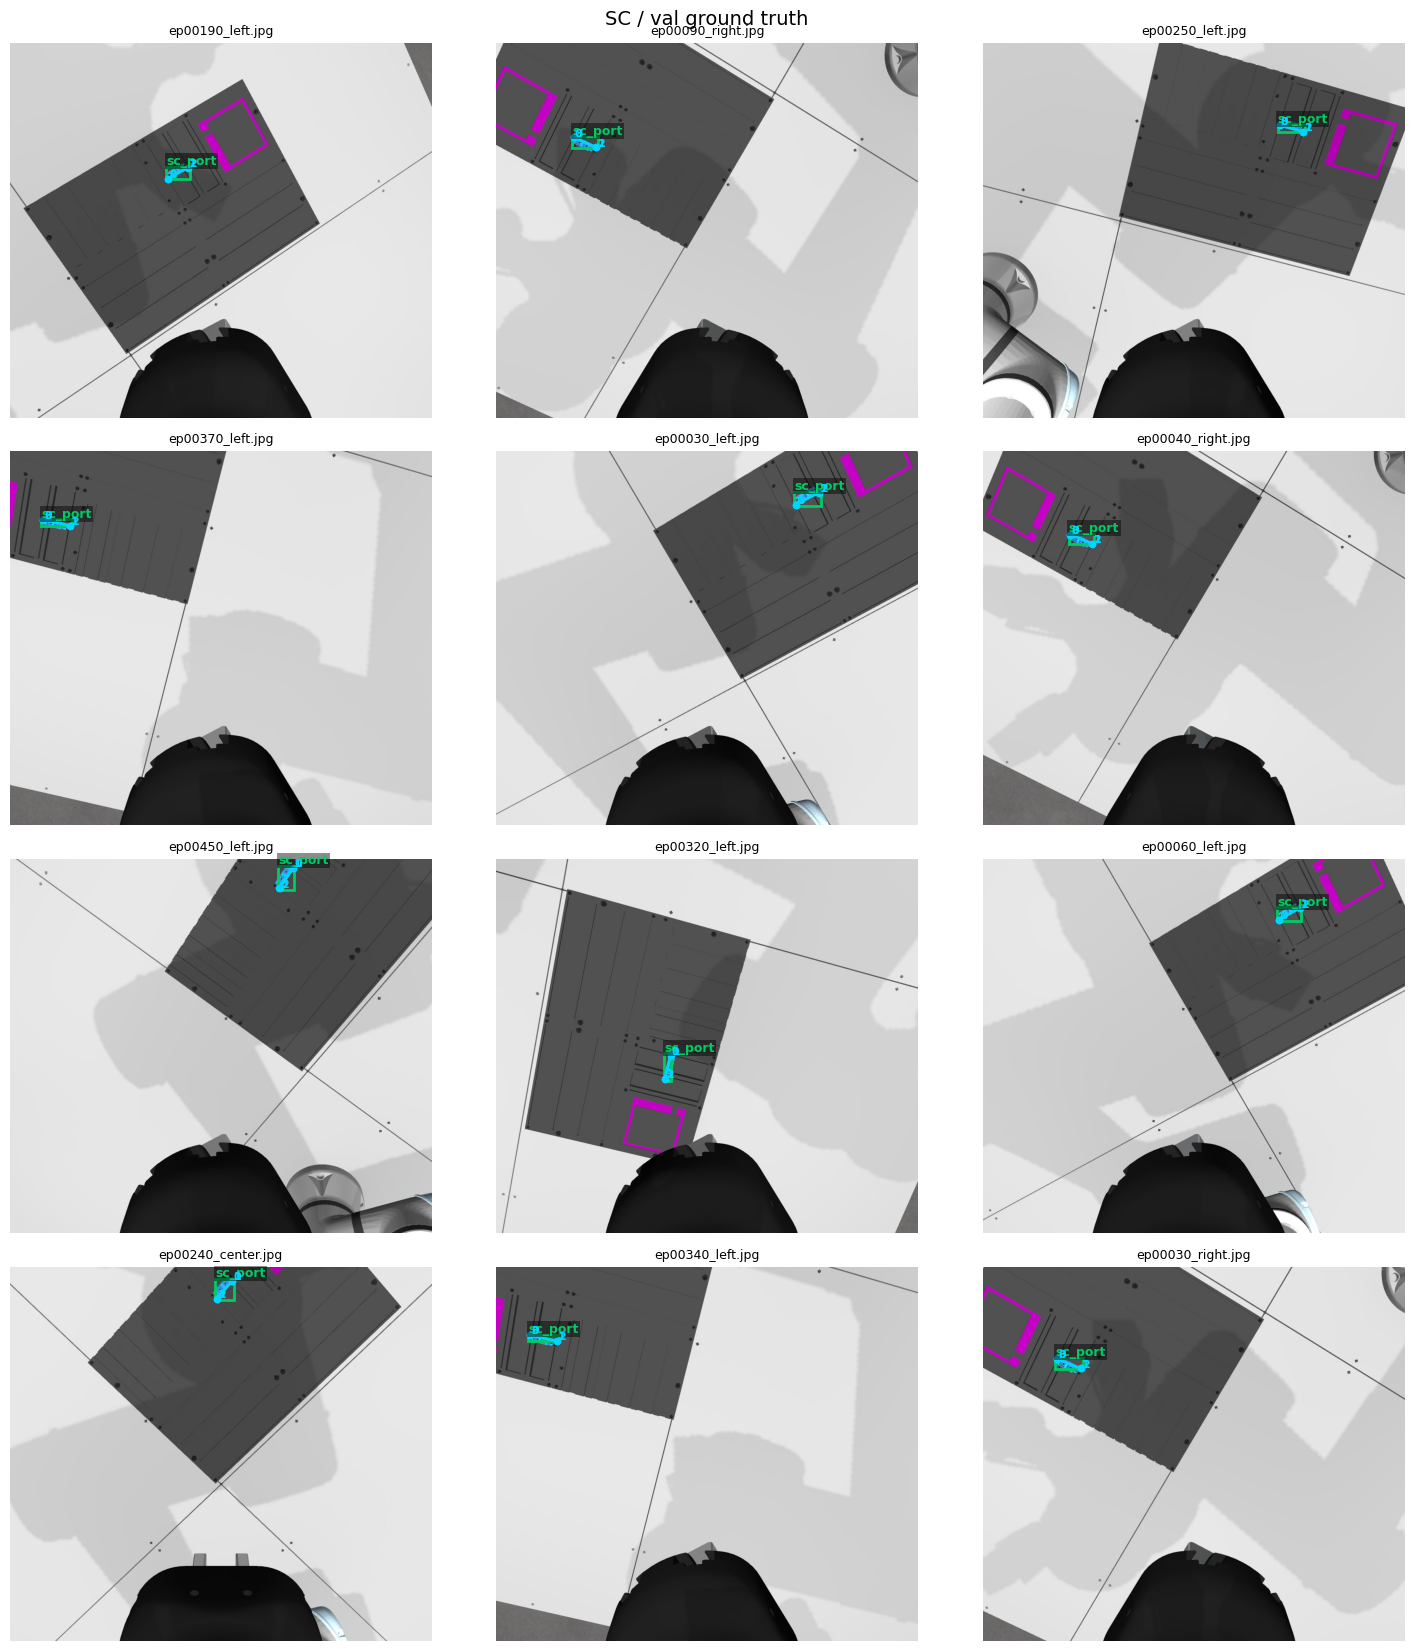

In [8]:
PORT_COLORS = {
    "port0": "#ffcc00",
    "port1": "#ff4fd8",
    "sc": "#00d5ff",
}
BOX_COLOR = "#00cc66"


def keypoint_groups(kpts: np.ndarray):
    if len(kpts) == 4:
        return [("sc", 0, 4)]
    return [("port0", 0, 4), ("port1", 4, 8)]


def draw_label(ax, label: dict, image_w: int, image_h: int) -> None:
    x, y, w, h = label["bbox_px"]
    ax.add_patch(Rectangle((x, y), w, h, fill=False, linewidth=2.0, edgecolor=BOX_COLOR))
    ax.text(
        x,
        max(0, y - 6),
        str(label["class_name"]),
        color=BOX_COLOR,
        fontsize=9,
        weight="bold",
        bbox={"facecolor": "black", "alpha": 0.45, "pad": 1, "edgecolor": "none"},
    )

    kpts = label["kpts_px"]
    if len(kpts) == 0:
        return
    for group_name, start, end in keypoint_groups(kpts):
        pts = kpts[start:end]
        color = PORT_COLORS[group_name]
        ax.add_patch(Polygon(pts, closed=True, fill=False, linewidth=2.0, edgecolor=color))
        for offset, (px, py) in enumerate(pts):
            kpt_idx = start + offset
            ax.scatter([px], [py], c=color, s=20)
            text = KEYPOINT_NAMES[kpt_idx] if SHOW_KEYPOINT_NAMES else str(kpt_idx)
            ax.text(px + 3, py - 3, text, color=color, fontsize=8, weight="bold")


def draw_image(ax, image_path: Path) -> None:
    image = plt.imread(image_path)
    image_h, image_w = image.shape[:2]
    label_path = label_path_for_image(image_path)
    labels = load_labels(label_path, image_w, image_h)

    ax.imshow(image)
    for label in labels:
        draw_label(ax, label, image_w, image_h)
    ax.set_title(image_path.name, fontsize=9)
    ax.set_axis_off()


def show_samples(split: str = SPLIT, n_samples: int = N_SAMPLES, seed: int = SEED) -> list[Path]:
    images = iter_images(split)
    if not images:
        raise RuntimeError(f"No images found for split={split!r} filter={IMAGE_FILTER!r}")

    rng = random.Random(seed)
    samples = rng.sample(images, min(n_samples, len(images)))
    cols = min(FIG_COLS, len(samples))
    rows = math.ceil(len(samples) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5.0 * cols, 4.2 * rows), squeeze=False)

    for ax in axes.ravel():
        ax.set_axis_off()
    for ax, image_path in zip(axes.ravel(), samples):
        draw_image(ax, image_path)

    fig.suptitle(f"{DATASET_DIR.name} / {split} ground truth", fontsize=14)
    fig.tight_layout()
    return samples


shown = show_samples()
shown[:3]


In [9]:
# Show one exact image by stem or filename fragment.
# Set QUERY to something like "ep00040_center" and run this cell.
QUERY = ""

if QUERY:
    matches = [p for split in ["train", "val"] for p in iter_images(split) if QUERY in p.name]
    if not matches:
        raise RuntimeError(f"No image matched QUERY={QUERY!r}")
    fig, ax = plt.subplots(1, 1, figsize=(8, 7))
    draw_image(ax, matches[0])
    fig.tight_layout()
    print(matches[0])
else:
    print("Set QUERY to visualize one exact sample.")

Set QUERY to visualize one exact sample.
